# Parameter estimation results

This notebook inspects the results from the various parameter estimation runs.


---

In [4]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import corner
import sys


def summary_stats(data_file):
    data = az.from_netcdf(data_file)
    summary_df = az.summary(data)
    print(summary_df)


def gw_posterior_plot(data_file):
    data = az.from_netcdf(data_file)

    samples = np.column_stack([
        data.posterior['ha'].values.flatten()
    ])

    print("Mean of selected parameters:")
    print(data.posterior['ha'].mean())

    # Transform to log space
    log_samples = np.log10(samples)

    # Set plot limits (adjust these values based on your data)
    ranges = [
        (-14, -10),  # ha limits
    ]


    # Create corner plot
    fig = corner.corner(
        log_samples,
        labels=['log(ha)'],
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_kwargs={"fontsize": 12},
        range=ranges,
        bins=30,  # Adjust number of bins as needed
        smooth=1.0,  # Adjust smoothing as needed
        plot_datapoints=True,
        fill_contours=True,
        levels=[0.68, 0.95]  # 1 and 2 sigma contours
    )

    plt.tight_layout()
    plt.show()



def efac_corner_plot(data_file):
    data = az.from_netcdf(data_file)

    efac_samples = data.posterior['EFAC'].values

    # Select first 3 EFAC components
    selected_efac_samples = np.column_stack([
        efac_samples[..., 0].flatten(),
        efac_samples[..., 1].flatten(),
        efac_samples[..., 2].flatten()
    ])

    # Create corner plot for EFAC parameters
    fig = corner.corner(
        selected_efac_samples,
        labels=['EFAC_0', 'EFAC_1', 'EFAC_2'],
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_kwargs={"fontsize": 12},
        bins=30,
        smooth=1.0,
        plot_datapoints=True,
        fill_contours=True,
        levels=[0.68, 0.95],  # 1 and 2 sigma contours
        range=[(0.5, 2.0), (0.5, 2.0), (0.5, 2.0)]  # Set axis limits for all three parameters
    )

    plt.tight_layout()
    plt.show()



def pulsar_noise_corner_plot(data_file):
    data = az.from_netcdf(data_file)

    pulsar_noise_samples = data.posterior['σp'].values

    # Transform to log space
    pulsar_noise_samples = np.log10(pulsar_noise_samples)

    # Set plot limits (adjust these values based on your data)
    ranges = [
        (-18, -12),  
    ]


    # Select first 5 pulsar noise components
    selected_efac_samples = np.column_stack([
        pulsar_noise_samples[..., 0].flatten(),
        pulsar_noise_samples[..., 1].flatten(),
        pulsar_noise_samples[..., 2].flatten(),
        pulsar_noise_samples[..., 3].flatten(),
        pulsar_noise_samples[..., 4].flatten()
    ])

    # Create corner plot for pulsar noise parameters
    fig = corner.corner(
        pulsar_noise_samples,
        labels=['σp_0', 'σp_1', 'σp_2', 'σp_3', 'σp_4'],
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        range=ranges,
        title_kwargs={"fontsize": 12},
    )
    


Mean of selected parameters:
<xarray.DataArray 'ha' ()> Size: 8B
array(1.00463717e-11)


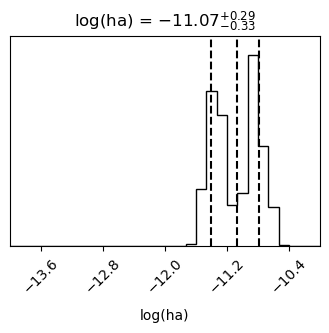

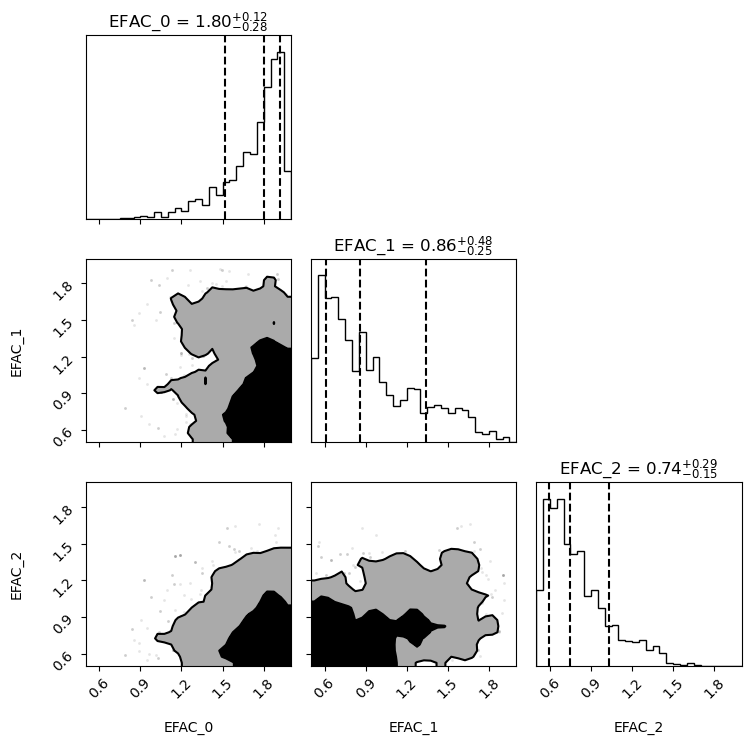

ValueError: Dimension mismatch between samples and range

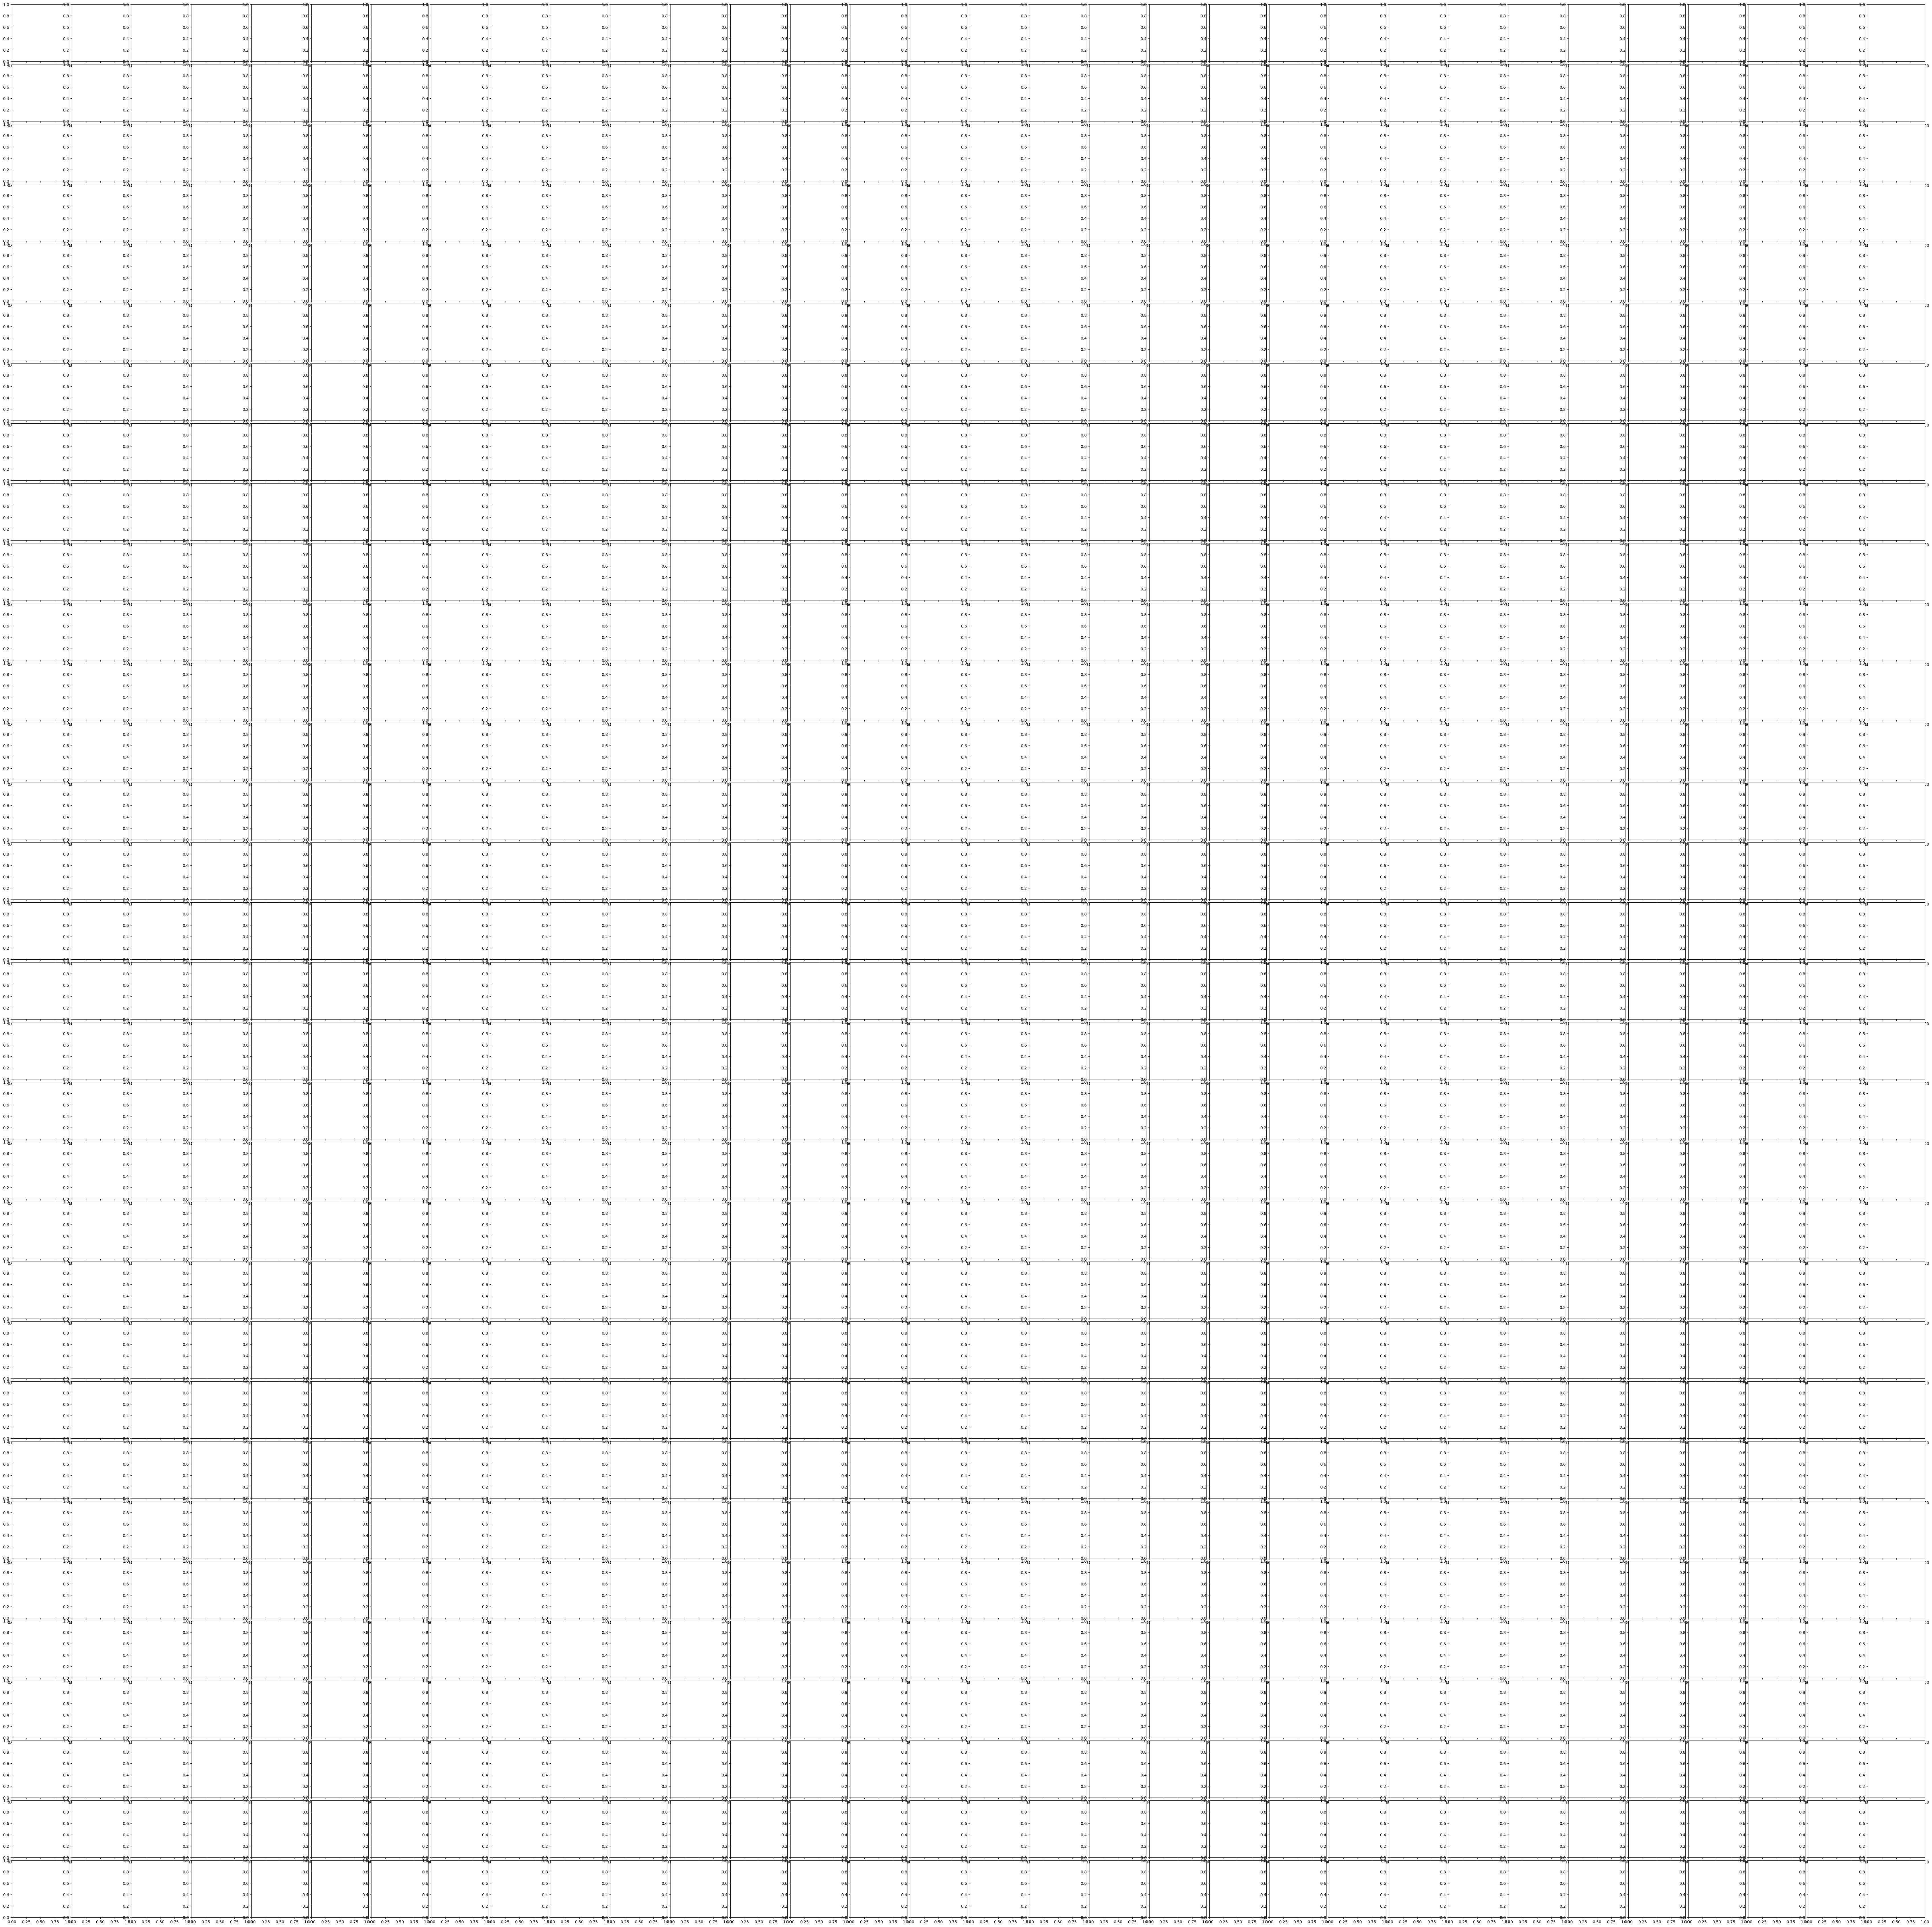

In [3]:
data_file = '../sandbox/outputs/test_parameter_estimation_results.nc'
#summary_stats(data_file)
gw_posterior_plot(data_file)
efac_corner_plot(data_file)
pulsar_noise_corner_plot(data_file)

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


          mean   sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
EFAC[0]  1.133  0.0   1.133    1.133        0.0      0.0    1000.0    1000.0   
EFAC[1]  1.260  0.0   1.260    1.260        0.0      0.0    1000.0    1000.0   
EFAC[2]  1.350  0.0   1.350    1.350        0.0      0.0    1000.0    1000.0   
EFAC[3]  0.903  0.0   0.903    0.903        0.0      0.0    1000.0    1000.0   
EFAC[4]  1.069  0.0   1.069    1.069        0.0      0.0    1000.0    1000.0   
...        ...  ...     ...      ...        ...      ...       ...       ...   
σp[27]   0.000  0.0   0.000    0.000        0.0      0.0    1000.0    1000.0   
σp[28]   0.000  0.0   0.000    0.000        0.0      0.0    1000.0    1000.0   
σp[29]   0.000  0.0   0.000    0.000        0.0      0.0    1000.0    1000.0   
σp[30]   0.000  0.0   0.000    0.000        0.0      0.0    1000.0    1000.0   
σp[31]   0.000  0.0   0.000    0.000        0.0      0.0    1000.0    1000.0   

         r_hat  
EFAC[0]    NaN  
EFAC[

/fred/oz022/tkimpson/conda_envs/Argus/lib/python3.12/site-packages/corner/core.py:928: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  return ax.set_ylim(new_ylim)


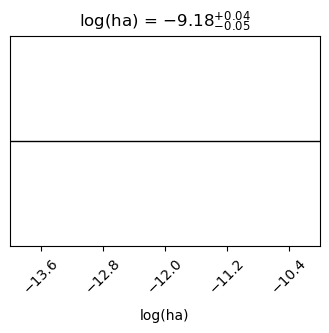

In [6]:

data_file = '../sandbox/outputs/test_parameter_estimation_results_2025-04-22_16-23-06.nc'
summary_stats(data_file)
gw_posterior_plot(data_file)


In [7]:
data = az.from_netcdf(data_file)

samples = np.column_stack([
    data.posterior['ha'].values.flatten()
])

print("Mean of selected parameters:")
print(data.posterior['ha'].mean())

# Transform to log space
log_samples = np.log10(samples)

# Set plot limits (adjust these values based on your data)
ranges = [
    (-14, -10),  # ha limits
]

Mean of selected parameters:
<xarray.DataArray 'ha' ()> Size: 8B
array(6.58847656e-10)


In [16]:
y = data.posterior['ha'].values

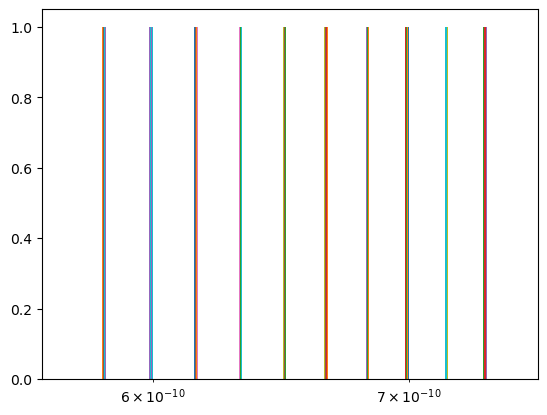

In [18]:
plt.hist(y)
plt.xscale('log')

In [19]:
y 

array([[7.48162088e-10, 7.48096325e-10, 7.48033874e-10, 7.47971098e-10,
        7.47711462e-10, 7.47650463e-10, 7.47585982e-10, 7.47521498e-10,
        7.47459802e-10, 7.47395915e-10, 7.47335489e-10, 7.47273153e-10,
        7.47208626e-10, 7.47140048e-10, 7.46890490e-10, 7.46822728e-10,
        7.46758444e-10, 7.46697363e-10, 7.46638001e-10, 7.46573692e-10,
        7.46311683e-10, 7.46247727e-10, 7.46182559e-10, 7.46124139e-10,
        7.46061688e-10, 7.45026134e-10, 7.45026134e-10, 7.44962290e-10,
        7.44896119e-10, 7.44830705e-10, 7.44760579e-10, 7.44694109e-10,
        7.44631708e-10, 7.44571348e-10, 7.44507212e-10, 7.43907325e-10,
        7.43836836e-10, 7.43570856e-10, 7.43305826e-10, 7.43305826e-10,
        7.42247768e-10, 7.42182170e-10, 7.42129652e-10, 7.42062045e-10,
        7.41997264e-10, 7.41930144e-10, 7.41868427e-10, 7.41806014e-10,
        7.41743336e-10, 7.41116574e-10, 7.40849397e-10, 7.40584297e-10,
        7.40584297e-10, 7.40516350e-10, 7.40451605e-10, 7.403864